#### 1) Importing Necessary Libraries:

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#### 2) Loading Data:

In [2]:
df = pd.read_csv('cluster_mpg.csv')

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 27.7+ KB


In [5]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


- All features except 'origin' are numerical.
- 'name' of the car has no use in clustering.
- We need to convert 'model_year' feature to age of the model for being more useful.

In [6]:
# Dropping 'name' feature:
df.drop('name', axis= 1, inplace= True)

In [7]:
# Converting 'model_year' feature to 'age_of_model' and dropping 'model_year':
df['age_of_model'] = 125 - df['model_year'] 
df.drop('model_year', axis= 1, inplace= True)

In [8]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,age_of_model
0,18.0,8,307.0,130.0,3504,12.0,usa,55
1,15.0,8,350.0,165.0,3693,11.5,usa,55
2,18.0,8,318.0,150.0,3436,11.0,usa,55
3,16.0,8,304.0,150.0,3433,12.0,usa,55
4,17.0,8,302.0,140.0,3449,10.5,usa,55


#### 3) Data Exploration and Transformations:

In [9]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,age_of_model
0,18.0,8,307.0,130.0,3504,12.0,usa,55
1,15.0,8,350.0,165.0,3693,11.5,usa,55
2,18.0,8,318.0,150.0,3436,11.0,usa,55
3,16.0,8,304.0,150.0,3433,12.0,usa,55
4,17.0,8,302.0,140.0,3449,10.5,usa,55


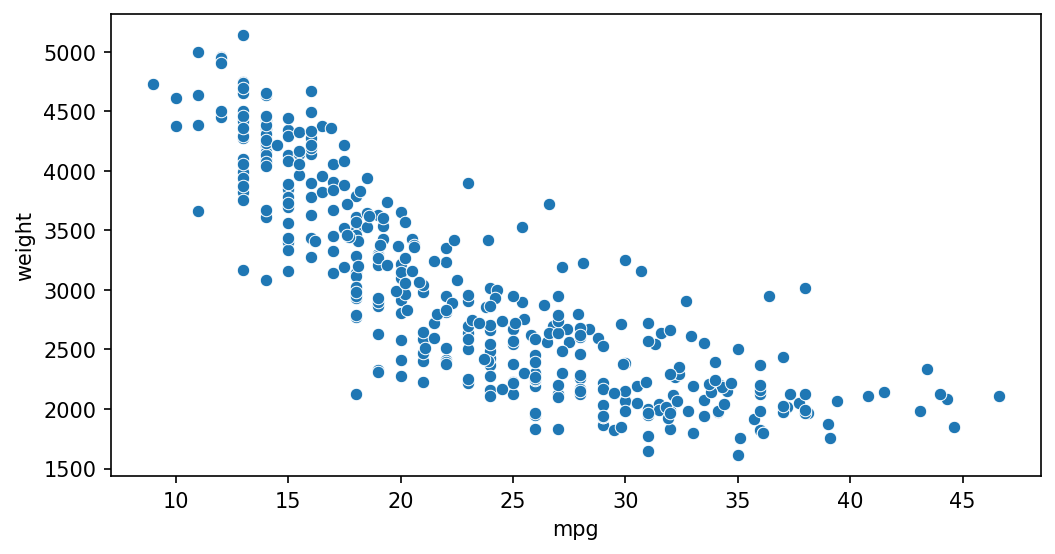

In [10]:
# 'MPG' vs 'Weight':

plt.figure(figsize= (8,4), dpi= 150)
sns.scatterplot(data= df, x= "mpg", y="weight")
plt.show()

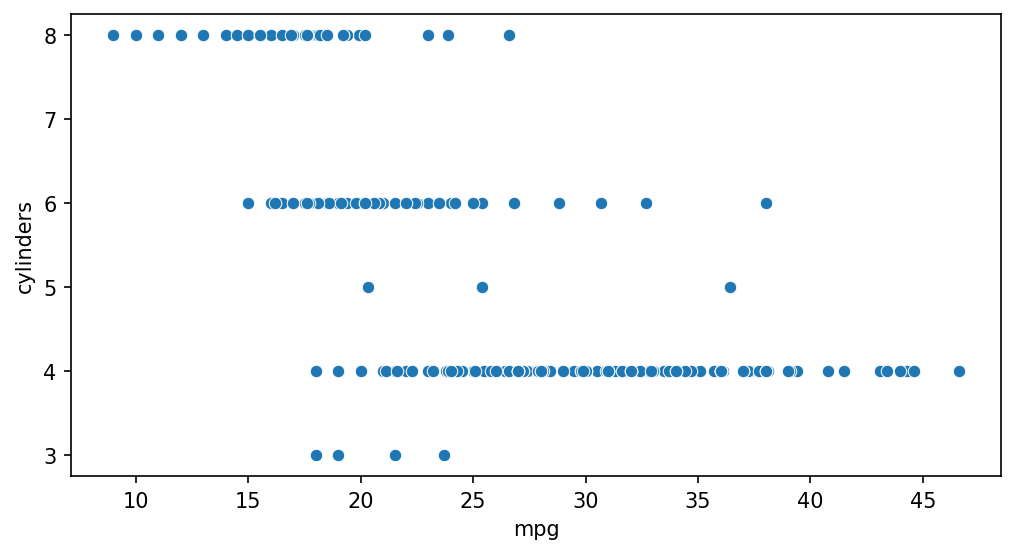

In [11]:
# 'MPG vs 'Number of Cylinders':

plt.figure(figsize= (8,4), dpi= 150)
sns.scatterplot(data= df, x= "mpg", y="cylinders")
plt.show()

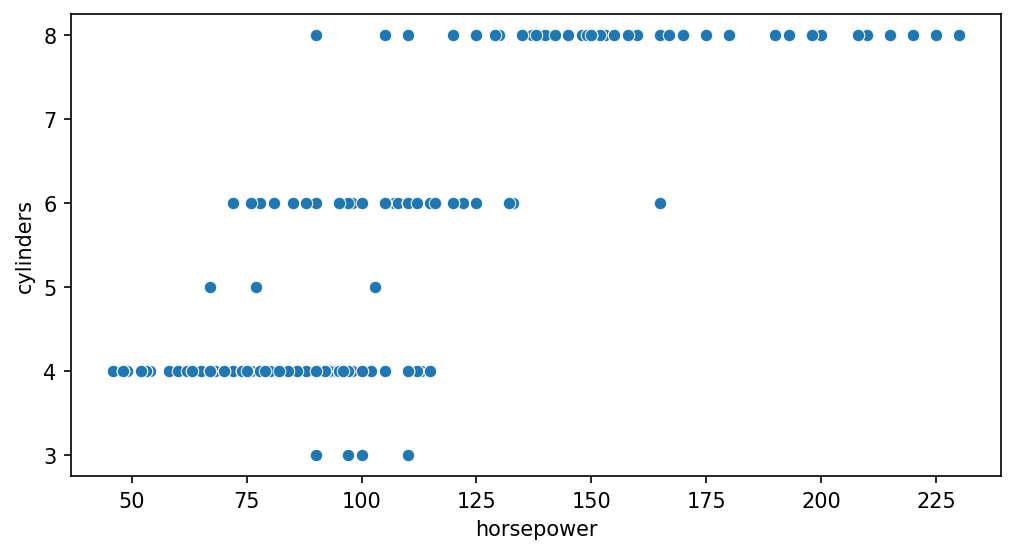

In [12]:
# 'HorsePower' vs 'Number of Cylinders':

plt.figure(figsize= (8,4), dpi= 150)
sns.scatterplot(data= df, x= "horsepower", y="cylinders")
plt.show()

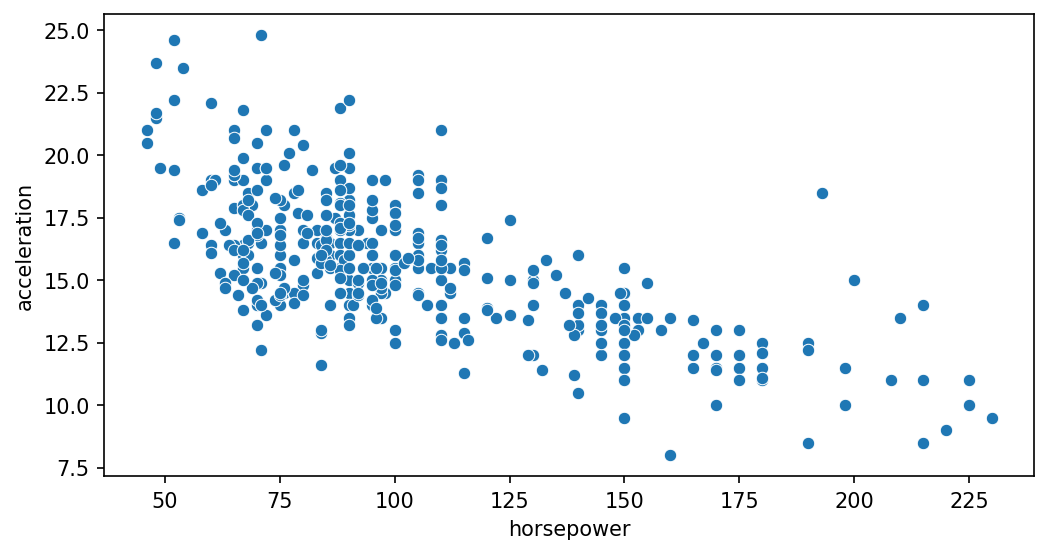

In [13]:
# 'HorsePower' vs 'Accelerartion Rate':

plt.figure(figsize= (8,4), dpi= 150)
sns.scatterplot(data= df, x= "horsepower", y="acceleration")
plt.show()

We have to encode 'Origin' feature. All other features are Numerical.

In [15]:
origin_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

numeric_pipe = Pipeline([
    ('scaler', MinMaxScaler())
])

In [18]:
preprocessor = ColumnTransformer([
    ('origin', origin_pipe, ['origin']),
    ('numeric_scaling', numeric_pipe, list(df.drop('origin', axis= 1).columns))
])

#### 4) Finding Optimal Number of Clusters:

In [19]:
# Preprocessing Data:

X = preprocessor.fit_transform(df)

In [20]:
# Looping through Different Number of Clusters to find Optimal Number

sil_score = []

for k in range(2, 26):
    agc = AgglomerativeClustering(n_clusters= k, linkage= 'ward') #Agglomerative Clustering Instance
    clusters = agc.fit_predict(X) #Fitting on Processed data
    sil_score.append(silhouette_score(X= X, labels= clusters))

In [24]:
sil_score

[0.47745879403803576,
 0.5654412305864407,
 0.5358884127590797,
 0.49378581815869443,
 0.4749366346005741,
 0.410587616145896,
 0.40618698214871785,
 0.3629830009709473,
 0.3598137176599912,
 0.3638008097105436,
 0.35057704949570523,
 0.3501640759562176,
 0.3370285181956755,
 0.3399657385103341,
 0.3291312045133952,
 0.3208168760615019,
 0.3053634163703033,
 0.29950780016055206,
 0.2889736980059113,
 0.2956886077958058,
 0.29719600106550653,
 0.2921754586156901,
 0.2894954166917141,
 0.2951584311979597]

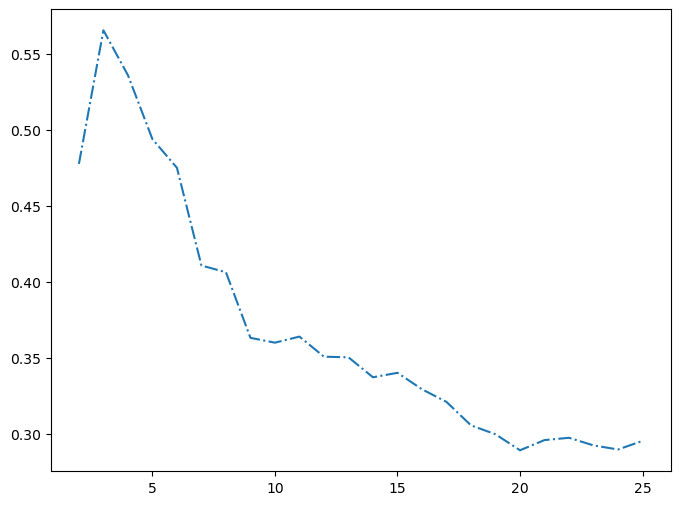

In [23]:
# Visualizing Silhouette Score:

plt.figure(figsize= (8,6))
sns.lineplot(x= range(2, 26), y= sil_score, ls= '-.')
plt.show()

3 is the Optimal Number of Cluster for this Dataset.

#### 5) Clustering:

In [25]:
agc = AgglomerativeClustering(n_clusters= 3)
clusters = agc.fit_predict(X)
clusters

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 2, 2, 2,
       2, 2, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 2, 2, 1, 1, 2, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 2, 2, 2, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 2, 0, 0, 2, 2, 2, 2, 0, 2, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 1, 1, 0, 2, 2, 1, 1, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 2, 1, 0, 2, 0, 2,
       2, 2, 2, 1, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0,
       0, 0, 0, 2, 1, 1, 0, 2, 0, 2, 1, 2, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 1, 2, 1, 2, 1,
       2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 1, 0, 0, 2, 0, 2, 0, 0, 0,

In [26]:
# Attaching Cluster Lables to Dataframe:

df['cluster'] = clusters

In [27]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,age_of_model,cluster
0,18.0,8,307.0,130.0,3504,12.0,usa,55,0
1,15.0,8,350.0,165.0,3693,11.5,usa,55,0
2,18.0,8,318.0,150.0,3436,11.0,usa,55,0
3,16.0,8,304.0,150.0,3433,12.0,usa,55,0
4,17.0,8,302.0,140.0,3449,10.5,usa,55,0


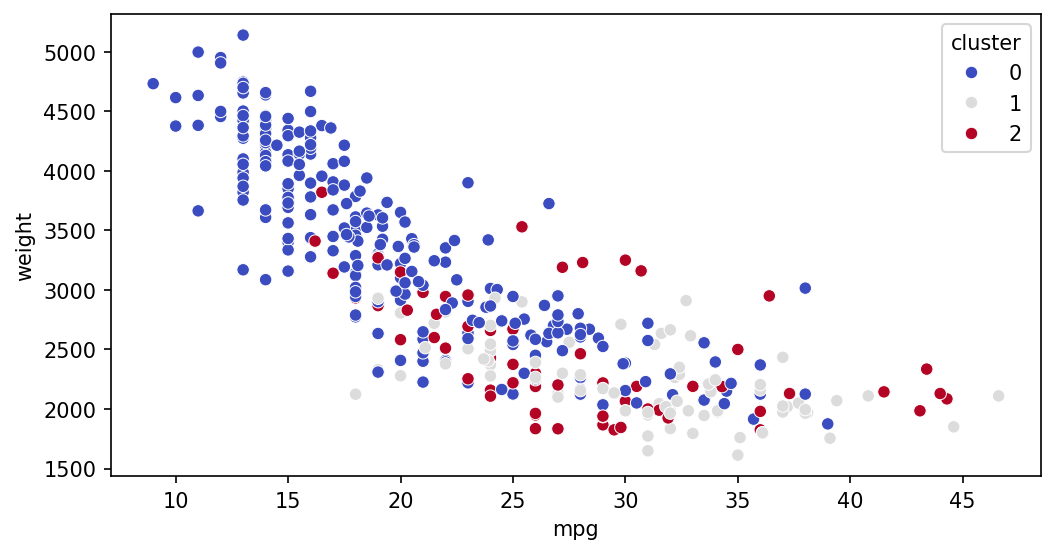

In [29]:
# Cluster wise 'MPG' and 'Weight':

plt.figure(figsize= (8,4), dpi= 150)
sns.scatterplot(data= df, x= "mpg", y="weight", hue= 'cluster', palette= 'coolwarm')
plt.show()

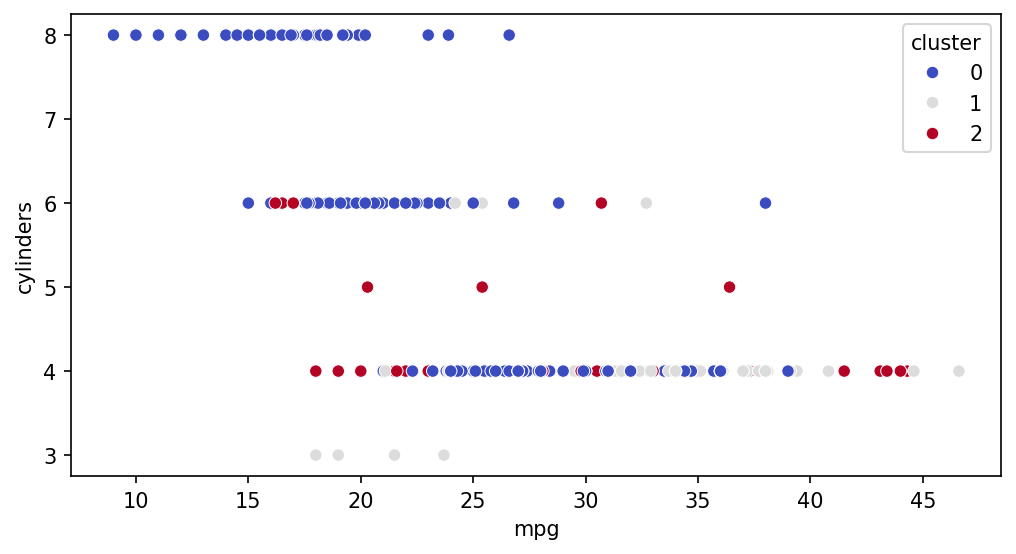

In [30]:
# Cluster wise 'MPG and 'Number of Cylinders':

plt.figure(figsize= (8,4), dpi= 150)
sns.scatterplot(data= df, x= "mpg", y="cylinders", hue= 'cluster', palette= 'coolwarm')
plt.show()

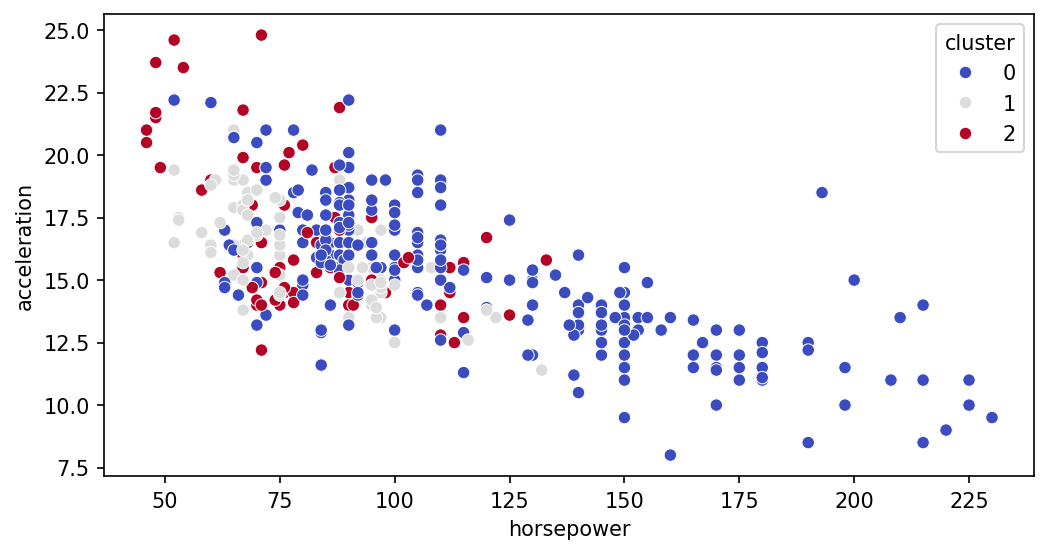

In [31]:
# Cluster wise 'HorsePower' and 'Accelerartion Rate':

plt.figure(figsize= (8,4), dpi= 150)
sns.scatterplot(data= df, x= "horsepower", y="acceleration", hue= 'cluster', palette= 'coolwarm')
plt.show()